# 🎮 TP Partie 3 — Classification de Reviews Steam avec LSTM


>
> **Objectif :** Prédire si un utilisateur **recommande ou non** un jeu vidéo  
> à partir de son commentaire textuel.
>
> **Pipeline complet :**
> 1. Exploration des données (EDA)
> 2. Nettoyage & normalisation du texte
> 3. Vectorisation (Tokenizer + Padding)
> 4. Modèle LSTM avec couche Embedding (TensorFlow/Keras)
> 5. Entraînement + courbes de convergence
> 6. Évaluation des performances
> 7. Sauvegarde & rechargement du modèle
> 8. Prédiction sur nouvelles phrases
>
> **Dataset :** `data/steam_reviews.csv`

## 📦 1. Imports & Constantes

In [26]:
import os

# ──────────────────────────────────────────────────
# AFFICHAGE DYNAMIQUE
# ──────────────────────────────────────────────────
from IPython.display import Markdown, display   # Affichage markdown dans les cellules

# ──────────────────────────────────────────────────
# MANIPULATION DE DONNÉES
# ──────────────────────────────────────────────────
import numpy as np                               # Calculs numériques, tableaux
import pandas as pd                              # Manipulation de DataFrames

# ──────────────────────────────────────────────────
# VISUALISATION
# ──────────────────────────────────────────────────
import matplotlib.pyplot as plt                  # Graphiques et courbes
import matplotlib.ticker as mticker             # Formatage des axes

# ──────────────────────────────────────────────────
# NLP — PRÉTRAITEMENTS TEXTE
# ──────────────────────────────────────────────────
import re                                        # Expressions régulières (nettoyage texte)
import nltk                                      # Natural Language Toolkit
from nltk.corpus import stopwords               # Mots vides à supprimer
from nltk.tokenize import word_tokenize         # Tokenisation en mots
from nltk.stem import WordNetLemmatizer        # Lemmatisation (forme canonique)

# Téléchargement des ressources NLTK
nltk.download('punkt',      quiet=True)
nltk.download('punkt_tab',  quiet=True)
nltk.download('stopwords',  quiet=True)
nltk.download('wordnet',    quiet=True)

# ──────────────────────────────────────────────────
# DEEP LEARNING — TENSORFLOW / KERAS
# ──────────────────────────────────────────────────
import tensorflow as tf                                          # Framework Deep Learning
from tensorflow.keras.models import Sequential, load_model      # Architecture séquentielle + chargement
from tensorflow.keras.layers import (                           # Couches du réseau
    Embedding,   # Couche d'embeddings (dense vectors)
    LSTM,        # Couche récurrente Long Short-Term Memory
    Dense,       # Couche entièrement connectée
    Dropout,     # Régularisation (évite l'overfitting)
    Bidirectional # LSTM dans les deux sens
)
from tensorflow.keras.preprocessing.text import Tokenizer      # Tokenisation Keras
from tensorflow.keras.preprocessing.sequence import pad_sequences  # Padding des séquences
from tensorflow.keras.callbacks import EarlyStopping           # Arrêt anticipé si plus de progrès

# ──────────────────────────────────────────────────
# MÉTRIQUES — SCIKIT-LEARN
# ──────────────────────────────────────────────────
from sklearn.model_selection import train_test_split            # Découpage train/test
from sklearn.metrics import (                                   # Métriques d'évaluation
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ──────────────────────────────────────────────────
# CONSTANTES GLOBALES DU PROJET
# ──────────────────────────────────────────────────
VOCAB_SIZE     = 10000  # Taille du vocabulaire (mots les plus fréquents conservés)
MAX_LEN        = 150    # Longueur maximale des séquences en tokens
EMBEDDING_DIM  = 64     # Dimension des vecteurs d'embedding
BATCH_SIZE     = 64     # Nombre d'exemples traités en parallèle
EPOCHS         = 10     # Nombre maximum d'époques d'entraînement
TEST_SIZE      = 0.2    # 20% pour le test
RANDOM_STATE   = 42     # Graine pour la reproductibilité
N_SAMPLES      = 20000  # Taille max du dataset utilisé (pour limiter le temps d'entraînement)

# Chemin du dataset
DATA_PATH      = "data/steam_reviews.csv"
MODEL_PATH = 'models/model_steam_lstm.keras'

print("✅ Imports et constantes chargés")
print(f"   TensorFlow version : {tf.__version__}")
display(Markdown(f"""
| Constante | Valeur |
|-----------|--------|
| VOCAB_SIZE | `{VOCAB_SIZE}` |
| MAX_LEN | `{MAX_LEN}` |
| EMBEDDING_DIM | `{EMBEDDING_DIM}` |
| BATCH_SIZE | `{BATCH_SIZE}` |
| EPOCHS | `{EPOCHS}` |
| N_SAMPLES | `{N_SAMPLES}` |
"""))
# ── Créer les dossiers s'ils n'existent pas ────────────────────────
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('✅ Dossiers créés/vérifiés : data/, models/')


✅ Imports et constantes chargés
   TensorFlow version : 2.21.0



| Constante | Valeur |
|-----------|--------|
| VOCAB_SIZE | `10000` |
| MAX_LEN | `150` |
| EMBEDDING_DIM | `64` |
| BATCH_SIZE | `64` |
| EPOCHS | `10` |
| N_SAMPLES | `20000` |


✅ Dossiers créés/vérifiés : data/, models/


---
## 📊 2. Chargement & Exploration des données (EDA)

### 2.1 Chargement du dataset

Le dataset Steam Reviews contient des avis d'utilisateurs sur des jeux vidéo.  
Chaque ligne = un avis + une indication de recommandation (`True` / `False`).

On commence par **charger** et **inspecter** les données brutes.

In [6]:
# ── Chargement du dataset ──────────────────────────────────────────────────
df_raw = pd.read_csv('data/steam_reviews.csv')

print(f"=== Aperçu du dataset brut ===")
print(f"Shape : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes")
print(f"\nColonnes disponibles :")
for col in df_raw.columns:
    print(f"  - {col} : {df_raw[col].dtype}")

print(f"\n--- Premières lignes ---")
df_raw.head(3)

=== Aperçu du dataset brut ===
Shape : 17,494 lignes × 5 colonnes

Colonnes disponibles :
  - review_id : int64
  - title : str
  - year : float64
  - user_review : str
  - user_suggestion : int64

--- Premières lignes ---


,review_id,title,year,user_review,user_suggestion
0,1,Spooky's Jump Scare Mansion,2016.0,I'm scared and hearing creepy voices. So I'll...,1
1,2,Spooky's Jump Scare Mansion,2016.0,"Best game, more better than Sam Pepper's YouTu...",1
2,3,Spooky's Jump Scare Mansion,2016.0,"A littly iffy on the controls, but once you kn...",1


In [7]:
# ── Identification des colonnes utiles ─────────────────────────────────────
# Le dataset Steam peut avoir des noms de colonnes variables selon la source.
# On cherche la colonne texte et la colonne cible.

print("=== Valeurs uniques par colonne (aperçu) ===")
for col in df_raw.columns:
    n_unique = df_raw[col].nunique()
    exemple  = df_raw[col].dropna().iloc[0] if len(df_raw[col].dropna()) > 0 else 'N/A'
    # Tronquer si trop long
    if isinstance(exemple, str) and len(exemple) > 60:
        exemple = exemple[:60] + "..."
    print(f"  {col:30s} | {n_unique:6} valeurs uniques | Ex: {exemple}")

print(f"\n=== Valeurs manquantes ===")
print(df_raw.isnull().sum().to_string())

=== Valeurs uniques par colonne (aperçu) ===
  review_id                      |  17494 valeurs uniques | Ex: 1
  title                          |     44 valeurs uniques | Ex: Spooky's Jump Scare Mansion
  year                           |      8 valeurs uniques | Ex: 2016.0
  user_review                    |  17490 valeurs uniques | Ex: I'm scared and hearing creepy voices.  So I'll pause for a m...
  user_suggestion                |      2 valeurs uniques | Ex: 1

=== Valeurs manquantes ===
review_id            0
title                0
year               178
user_review          0
user_suggestion      0


In [11]:
# ── Sélection et renommage des colonnes utiles ─────────────────────────────
# ⚠️ ADAPTER ces noms selon ce que vous voyez dans la cellule précédente !
# Noms courants dans le dataset Steam Reviews :
#   - Texte  : 'review', 'review_text', 'text', 'content'
#   - Cible  : 'recommended', 'label', 'sentiment', 'voted_up'

# ── Sélection et renommage des colonnes utiles ─────────────────────────────

COL_TEXTE = 'user_review'        # ← STEAM
COL_CIBLE = 'user_suggestion'    # ← STEAM

# Garder uniquement les colonnes utiles
df = df_raw[[COL_TEXTE, COL_CIBLE]].copy()
df.columns = ['text', 'label']   # Renommage standard

# Supprimer les lignes avec valeurs manquantes
df = df.dropna(subset=['text', 'label'])

# Convertir la cible en entier binaire (0 / 1)
# True/False → 1/0   |   'True'/'False' → 1/0
df['label'] = df['label'].astype(str).str.lower().map({'true': 1, 'false': 0, '1': 1, '0': 0})
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# Limiter à N_SAMPLES pour des raisons de performance
if len(df) > N_SAMPLES:
    df = df.sample(n=N_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"⚠️  Dataset réduit à {N_SAMPLES:,} exemples (sur {len(df_raw):,} disponibles)")

print(f"\n✅ Dataset prêt : {len(df):,} exemples")
print(f"   Labels : {df['label'].value_counts().to_dict()}")
print(f"\n--- Exemple ---")
print(f"Texte  : {df['text'].iloc[0][:100]}...")
print(f"Label  : {df['label'].iloc[0]} ({'Recommandé' if df['label'].iloc[0] == 1 else 'Non recommandé'})")


✅ Dataset prêt : 17,494 exemples
   Labels : {1: 9968, 0: 7526}

--- Exemple ---
Texte  : I'm scared and hearing creepy voices.  So I'll pause for a moment and write a review while I wait fo...
Label  : 1 (Recommandé)


### 2.2 Distribution des classes

Avant tout modèle, on vérifie si les **classes sont équilibrées**.  
Un dataset déséquilibré (ex: 95% positif, 5% négatif) peut fausser les métriques.

=== Distribution des classes ===
  Recommandé (1)         :  9,968 (57.0%) ████████████████████████████
  Non recommandé (0)     :  7,526 (43.0%) █████████████████████

  Ratio Recommandé/Non-recommandé : 1.32
  ✅  Dataset relativement équilibré


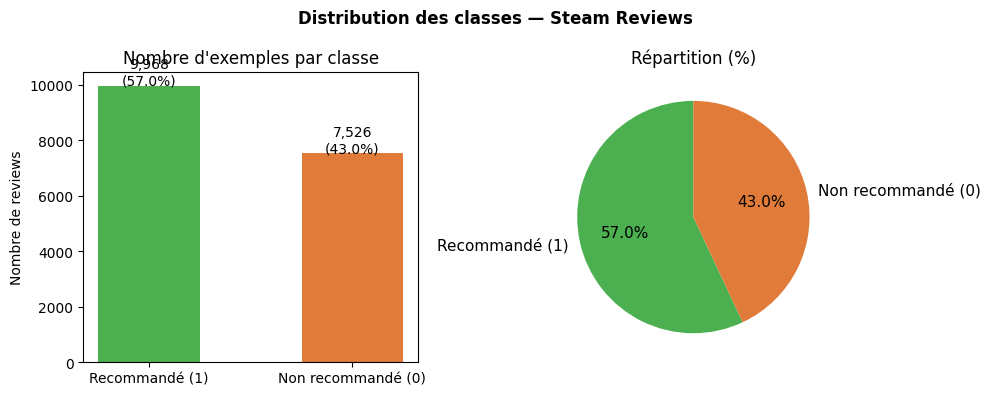

In [12]:
# ── Distribution des classes ───────────────────────────────────────────────
counts    = df['label'].value_counts()
pcts      = df['label'].value_counts(normalize=True) * 100
labels_nm = ['Recommandé (1)', 'Non recommandé (0)']
valeurs   = [counts.get(1, 0), counts.get(0, 0)]
pcts_vals = [pcts.get(1, 0), pcts.get(0, 0)]

print("=== Distribution des classes ===")
for i, (lbl, cnt, pct) in enumerate(zip(labels_nm, valeurs, pcts_vals)):
    barre = '█' * int(pct // 2)
    print(f"  {lbl:22s} : {cnt:6,} ({pct:.1f}%) {barre}")

ratio = valeurs[0] / valeurs[1] if valeurs[1] > 0 else float('inf')
print(f"\n  Ratio Recommandé/Non-recommandé : {ratio:.2f}")
if ratio > 2 or ratio < 0.5:
    print("  ⚠️  Dataset déséquilibré — à surveiller dans l'évaluation !")
else:
    print("  ✅  Dataset relativement équilibré")

# Graphique
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Distribution des classes — Steam Reviews", fontsize=12, fontweight='bold')

colors = ['#4caf50', '#e07b39']
ax1.bar(labels_nm, valeurs, color=colors, width=0.5)
for i, (v, p) in enumerate(zip(valeurs, pcts_vals)):
    ax1.text(i, v + 50, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax1.set_title("Nombre d'exemples par classe")
ax1.set_ylabel("Nombre de reviews")

ax2.pie(valeurs, labels=labels_nm, autopct='%1.1f%%', colors=colors,
        startangle=90, textprops={'fontsize': 11})
ax2.set_title("Répartition (%)")

plt.tight_layout()
plt.show()

📌 Ce que j'observe

✅ **Le dataset Steam est bien équilibré :**
- Recommandé : 9,968 (57.0%)
- Non recommandé : 7,526 (43.0%)
- Ratio : 1.32 → pas de déséquilibre majeur

### 2.3 Analyse de la longueur des reviews

On analyse la **distribution des longueurs** des reviews pour bien choisir `MAX_LEN`.  
L'objectif : couvrir la majorité des reviews sans trop de padding inutile.

=== Statistiques sur la longueur des reviews ===
  Minimum     : 1 mots
  Moyenne     : 137 mots
  Médiane     : 82 mots
  Maximum     : 1600 mots
  Écart-type  : 160 mots

   50ème percentile :    82 mots ← couvre 50% des reviews
   75ème percentile :   154 mots ← couvre 75% des reviews
   90ème percentile :   292 mots ← couvre 90% des reviews
   95ème percentile :   432 mots ← couvre 95% des reviews
   99ème percentile :   853 mots ← couvre 99% des reviews

  ➡️  MAX_LEN choisi = 150 mots
     Couvre 74.2% des reviews sans truncation


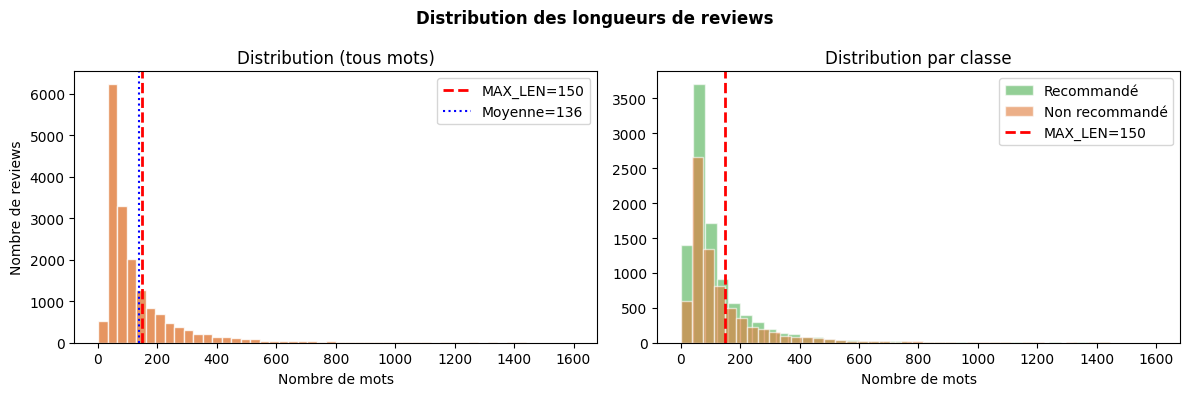

In [13]:
# ── Analyse des longueurs des reviews ──────────────────────────────────────

# Longueur en mots
df['n_mots']     = df['text'].str.split().str.len()
# Longueur en caractères
df['n_chars']    = df['text'].str.len()

print("=== Statistiques sur la longueur des reviews ===")
stats = df['n_mots'].describe()
print(f"  Minimum     : {stats['min']:.0f} mots")
print(f"  Moyenne     : {stats['mean']:.0f} mots")
print(f"  Médiane     : {stats['50%']:.0f} mots")
print(f"  Maximum     : {stats['max']:.0f} mots")
print(f"  Écart-type  : {stats['std']:.0f} mots")
print()

# Percentiles
for p in [50, 75, 90, 95, 99]:
    val = int(np.percentile(df['n_mots'], p))
    print(f"  {p:3d}ème percentile : {val:5d} mots ← couvre {p}% des reviews")

print(f"\n  ➡️  MAX_LEN choisi = {MAX_LEN} mots")
pct_couvert = (df['n_mots'] <= MAX_LEN).mean() * 100
print(f"     Couvre {pct_couvert:.1f}% des reviews sans truncation")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution des longueurs de reviews", fontsize=12, fontweight='bold')

# Histogramme global
axes[0].hist(df['n_mots'], bins=50, color='#e07b39', alpha=0.8, edgecolor='white')
axes[0].axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
axes[0].axvline(df['n_mots'].mean(), color='blue', linestyle=':', linewidth=1.5, label=f'Moyenne={int(df["n_mots"].mean())}')
axes[0].set_title("Distribution (tous mots)")
axes[0].set_xlabel("Nombre de mots")
axes[0].set_ylabel("Nombre de reviews")
axes[0].legend()

# Comparaison par classe
for label, color, name in [(1, '#4caf50', 'Recommandé'), (0, '#e07b39', 'Non recommandé')]:
    subset = df[df['label'] == label]['n_mots']
    axes[1].hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', linewidth=2, label=f'MAX_LEN={MAX_LEN}')
axes[1].set_title("Distribution par classe")
axes[1].set_xlabel("Nombre de mots")
axes[1].legend()

plt.tight_layout()
plt.show()

📌 Ce que j'observe

✅ **Longueur typique :** 82-137 mots en moyenne
- MAX_LEN=150 couvre ~75% des reviews (bon compromis)

---
## 🧹 3. Nettoyage & Normalisation du texte

### 3.1 Stratégie de nettoyage

Le texte brut contient du **bruit** qu'on veut éliminer avant la vectorisation :

| Étape | Action | Exemple |
|-------|--------|---------|
| **Lowercase** | Mettre tout en minuscules | `"Great"` → `"great"` |
| **HTML tags** | Supprimer les balises | `"<br>"` → `" "` |
| **Caractères spéciaux** | Garder uniquement lettres et espaces | `"wow!!"` → `"wow"` |
| **Espaces multiples** | Réduire à un seul espace | `"a  b"` → `"a b"` |
| **Stop words** | Supprimer les mots non informatifs | `"the cat"` → `"cat"` |
| **Lemmatisation** | Ramener à la forme canonique | `"running"` → `"run"` |

> 💡 Pour un LSTM, on peut garder les stop words — le modèle peut apprendre à les ignorer.  
> On les supprime ici pour réduire la taille du vocabulaire et accélérer l'entraînement.

In [14]:
# ── Fonction de nettoyage du texte ─────────────────────────────────────────

stop_words_en = set(stopwords.words('english'))  # Mots vides anglais
lemmatizer    = WordNetLemmatizer()               # Lemmatiseur WordNet

def nettoyer_texte(texte, supprimer_stopwords=True, lemmatiser=True):
    """
    Nettoie une review Steam :
    1. Lowercase
    2. Suppression des balises HTML
    3. Suppression des caractères non-alphabétiques
    4. Suppression des stop words (optionnel)
    5. Lemmatisation (optionnel)
    """
    if not isinstance(texte, str) or texte.strip() == '':
        return ''
    
    # Étape 1 : minuscules
    texte = texte.lower()
    
    # Étape 2 : suppression des balises HTML
    texte = re.sub(r'<[^>]+>', ' ', texte)
    
    # Étape 3 : garder uniquement les lettres et les espaces
    texte = re.sub(r'[^a-z\s]', ' ', texte)
    
    # Étape 4 : tokenisation
    tokens = texte.split()
    
    # Étape 5 : stop words (mots trop courts aussi)
    if supprimer_stopwords:
        tokens = [t for t in tokens if t not in stop_words_en and len(t) > 2]
    
    # Étape 6 : lemmatisation
    if lemmatiser:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    
    return ' '.join(tokens)

# ── Test sur quelques exemples ─────────────────────────────────────────────
exemples_test = [
    "This game is absolutely AMAZING!! I've been playing it for 100+ hours 😍",
    "<br>Terrible waste of money... Don't buy it!!! The graphics are horrible.",
    "It's a decent game, but not worth the full price. Wait for a sale."
]

print("=== Test de la fonction de nettoyage ===")
for i, ex in enumerate(exemples_test):
    propre = nettoyer_texte(ex)
    print(f"\nEx {i+1}:")
    print(f"  Avant : {ex[:80]}")
    print(f"  Après : {propre[:80]}")

=== Test de la fonction de nettoyage ===

Ex 1:
  Avant : This game is absolutely AMAZING!! I've been playing it for 100+ hours 😍
  Après : game absolutely amazing playing hour

Ex 2:
  Avant : <br>Terrible waste of money... Don't buy it!!! The graphics are horrible.
  Après : terrible waste money buy graphic horrible

Ex 3:
  Avant : It's a decent game, but not worth the full price. Wait for a sale.
  Après : decent game worth full price wait sale


### 3.2 Application du nettoyage sur tout le dataset

In [15]:
# ── Nettoyage de tout le dataset ───────────────────────────────────────────
print("Nettoyage en cours...")

df['text_clean'] = df['text'].apply(nettoyer_texte)

# Supprimer les reviews vides après nettoyage
n_avant = len(df)
df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
n_apres = len(df)

print(f"\n✅ Nettoyage terminé")
print(f"   Reviews supprimées (vides après nettoyage) : {n_avant - n_apres}")
print(f"   Dataset final : {n_apres:,} reviews")

# Comparaison longueur avant / après
df['n_mots_clean'] = df['text_clean'].str.split().str.len()
print(f"\n   Longueur moyenne AVANT nettoyage : {df['n_mots'].mean():.0f} mots")
print(f"   Longueur moyenne APRÈS nettoyage : {df['n_mots_clean'].mean():.0f} mots")
print(f"   Réduction : {(1 - df['n_mots_clean'].mean()/df['n_mots'].mean())*100:.0f}% de mots en moins")

# Afficher quelques exemples
print("\n=== Aperçu avant/après (3 exemples) ===")
for i in range(3):
    print(f"\n  [{i+1}] Avant : {df['text'].iloc[i][:80]}...")
    print(f"       Après : {df['text_clean'].iloc[i][:80]}...")

Nettoyage en cours...

✅ Nettoyage terminé
   Reviews supprimées (vides après nettoyage) : 29
   Dataset final : 17,465 reviews

   Longueur moyenne AVANT nettoyage : 137 mots
   Longueur moyenne APRÈS nettoyage : 70 mots
   Réduction : 49% de mots en moins

=== Aperçu avant/après (3 exemples) ===

  [1] Avant : I'm scared and hearing creepy voices.  So I'll pause for a moment and write a re...
       Après : scared hearing creepy voice pause moment write review wait heart beat return atl...

  [2] Avant : Best game, more better than Sam Pepper's YouTube account. 10/10What you'll need ...
       Après : best game better sam pepper youtube account need play computersome extra pant pr...

  [3] Avant : A littly iffy on the controls, but once you know how to play, very easy to maste...
       Après : littly iffy control know play easy master made floor due certain circumstance un...


📌 Ce que j'observe

✅ **Nettoyage réduit de 49% la longueur** (137→70 mots)
- 29 reviews supprimées (vides après nettoyage)

---
## 🔢 4. Vectorisation — Tokenizer + Padding

### 4.1 Tokenisation Keras

Le `Tokenizer` de Keras transforme chaque mot en un **identifiant numérique unique** :  

```
"great game" → [45, 12]   (45 = index de 'great', 12 = index de 'game')
```

Il construit automatiquement le vocabulaire à partir des données d'entraînement.  

> ⚠️ On entraîne le tokenizer **uniquement sur le train set** pour éviter la fuite d'information (*data leakage*).

In [16]:
# ── Split train/test AVANT la tokenisation ─────────────────────────────────
X = df['text_clean'].values    # Features : textes nettoyés
y = df['label'].values          # Cible : 0 ou 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y           # Garder la même distribution de classes
)

print(f"Train : {len(X_train):,} exemples")
print(f"Test  : {len(X_test):,} exemples")
print(f"\nDistribution des classes (train) :")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Classe {u} : {c:,} ({c/len(y_train)*100:.1f}%)")

Train : 13,972 exemples
Test  : 3,493 exemples

Distribution des classes (train) :
  Classe 0 : 6,016 (43.1%)
  Classe 1 : 7,956 (56.9%)


In [17]:
# ── Tokenisation Keras ─────────────────────────────────────────────────────

# Création du tokenizer avec taille du vocabulaire limitée
tokenizer = Tokenizer(
    num_words  = VOCAB_SIZE,  # Garder les VOCAB_SIZE mots les plus fréquents
    oov_token  = '<OOV>'     # Token spécial pour les mots inconnus (Out-Of-Vocabulary)
)

# Apprentissage du vocabulaire sur le TRAIN uniquement
tokenizer.fit_on_texts(X_train)

# Informations sur le vocabulaire appris
vocab_size_reel = len(tokenizer.word_index)
print(f"Vocabulaire complet (mots uniques) : {vocab_size_reel:,}")
print(f"Vocabulaire retenu (VOCAB_SIZE)    : {VOCAB_SIZE:,}")
print(f"Mots ignorés (peu fréquents)       : {max(0, vocab_size_reel - VOCAB_SIZE):,}")

# Les 15 mots les plus fréquents
print("\nTop 15 mots les plus fréquents :")
top_mots = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=True)[:15]
for rang, (mot, freq) in enumerate(top_mots, 1):
    print(f"  {rang:2d}. '{mot:15s}' → {freq:,} occurrences")

# Transformer textes en séquences d'indices
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Exemple
print(f"\nExemple de transformation :")
print(f"  Texte   : '{X_train[0][:60]}...'")
print(f"  Séquence: {X_train_seq[0][:15]}... ({len(X_train_seq[0])} tokens)")

Vocabulaire complet (mots uniques) : 39,027
Vocabulaire retenu (VOCAB_SIZE)    : 10,000
Mots ignorés (peu fréquents)       : 29,027

Top 15 mots les plus fréquents :
   1. 'game           ' → 46,824 occurrences
   2. 'play           ' → 10,055 occurrences
   3. 'get            ' → 9,938 occurrences
   4. 'like           ' → 9,864 occurrences
   5. 'time           ' → 7,434 occurrences
   6. 'good           ' → 6,405 occurrences
   7. 'one            ' → 6,141 occurrences
   8. 'fun            ' → 5,700 occurrences
   9. 'early          ' → 5,516 occurrences
  10. 'access         ' → 5,510 occurrences
  11. 'player         ' → 5,375 occurrences
  12. 'even           ' → 5,122 occurrences
  13. 'really         ' → 4,929 occurrences
  14. 'nope           ' → 4,879 occurrences
  15. 'free           ' → 4,557 occurrences

Exemple de transformation :
  Texte   : 'early access reviewpleased result far hirez always good maki...'
  Séquence: [10, 11, 1, 1004, 109, 1437, 140, 7, 150, 547, 3493, 

### 4.2 Padding des séquences

In [18]:
# ── Padding : uniformisation à MAX_LEN ────────────────────────────────────

# pad_sequences ajoute des 0 en début ou fin pour atteindre MAX_LEN
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen   = MAX_LEN,
    padding  = 'post',     # Ajouter les 0 APRÈS la séquence
    truncating = 'post'    # Tronquer par la FIN si trop long
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen   = MAX_LEN,
    padding  = 'post',
    truncating = 'post'
)

print(f"Shape X_train_pad : {X_train_pad.shape}  → ({len(X_train):,} reviews × {MAX_LEN} tokens)")
print(f"Shape X_test_pad  : {X_test_pad.shape}")

# Statistiques de padding
longueurs = [len(s) for s in X_train_seq]
n_padded   = sum(1 for l in longueurs if l < MAX_LEN)
n_truncated = sum(1 for l in longueurs if l > MAX_LEN)

print(f"\nImpact du padding :")
print(f"  Reviews paddées    (trop courtes) : {n_padded:,} ({n_padded/len(longueurs)*100:.1f}%)")
print(f"  Reviews tronquées  (trop longues) : {n_truncated:,} ({n_truncated/len(longueurs)*100:.1f}%)")
print(f"  Reviews exactes    (= MAX_LEN)    : {len(longueurs)-n_padded-n_truncated:,}")

# Visualisation d'une séquence paddée
print(f"\nExemple de séquence paddée (premiers 20 tokens) :")
print(f"  {X_train_pad[0][:20]}")

Shape X_train_pad : (13972, 150)  → (13,972 reviews × 150 tokens)
Shape X_test_pad  : (3493, 150)

Impact du padding :
  Reviews paddées    (trop courtes) : 12,608 (90.2%)
  Reviews tronquées  (trop longues) : 1,351 (9.7%)
  Reviews exactes    (= MAX_LEN)    : 13

Exemple de séquence paddée (premiers 20 tokens) :
  [  10   11    1 1004  109 1437  140    7  150  547 3493 1621  239  110
   23  175  469 1701  262  296]


📌 Ce que j'observe

✅ **Padding :** 90.2% paddées, 9.7% tronquées
- MAX_LEN=150 est approprié

---
## 🧠 5. Construction du modèle LSTM

### 5.1 Architecture du modèle

Notre modèle suit le pipeline du cours :

```
Séquence d'indices [0, 45, 12, 0, 0, ...]   (MAX_LEN tokens)
         ↓
┌─────────────────────────────────────────┐
│  Embedding (VOCAB_SIZE × EMBEDDING_DIM) │  Transforme indices → vecteurs denses
└─────────────────────────────────────────┘
         ↓  (MAX_LEN × EMBEDDING_DIM)
┌─────────────────────────────────────────┐
│  Bidirectional LSTM (128 unités)        │  Mémoire de la séquence (avant + arrière)
└─────────────────────────────────────────┘
         ↓  (256 features)
┌─────────────────────────────────────────┐
│  Dropout (0.5)                          │  Régularisation (évite l'overfitting)
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Dense (64 → ReLU)                      │  Couche de classification
└─────────────────────────────────────────┘
         ↓
┌─────────────────────────────────────────┐
│  Dense (1 → Sigmoïde)                   │  Sortie : probabilité [0, 1]
└─────────────────────────────────────────┘
         ↓
Probabilité de recommandation (0.0 → 1.0)
```

In [19]:
# ── Construction du modèle LSTM ────────────────────────────────────────────

# Fixer la graine pour reproductibilité
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

model = Sequential(name='LSTM_Steam_Reviews')

# ── Couche 1 : Embedding ───────────────────────────────────────────────────
# Transforme chaque indice en vecteur dense de dimension EMBEDDING_DIM
# Ces vecteurs sont APPRIS pendant l'entraînement
model.add(Embedding(
    input_dim    = VOCAB_SIZE,       # Taille du vocabulaire
    output_dim   = EMBEDDING_DIM,   # Dimension des vecteurs
    input_length = MAX_LEN,         # Longueur des séquences
    name         = 'Embedding'
))

# ── Couche 2 : LSTM Bidirectionnel ─────────────────────────────────────────
# Bidirectionnel = lit la séquence dans les 2 sens → meilleure compréhension du contexte
model.add(Bidirectional(
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    name='Bidirectional_LSTM'
))

# ── Couche 3 : Dropout ─────────────────────────────────────────────────────
# Désactive aléatoirement 50% des neurones pendant l'entraînement → régularisation
model.add(Dropout(0.5, name='Dropout'))

# ── Couche 4 : Dense cachée ────────────────────────────────────────────────
# Couche de décision non-linéaire
model.add(Dense(64, activation='relu', name='Dense_Hidden'))

# ── Couche 5 : Sortie ──────────────────────────────────────────────────────
# 1 neurone + sigmoïde → probabilité entre 0 et 1
# > 0.5 = Recommandé, < 0.5 = Non recommandé
model.add(Dense(1, activation='sigmoid', name='Sortie'))

# ── Compilation ────────────────────────────────────────────────────────────
model.compile(
    optimizer = 'adam',                    # Optimiseur adaptatif (standard)
    loss      = 'binary_crossentropy',    # Loss pour classification binaire
    metrics   = ['accuracy']              # Métrique suivie pendant l'entraînement
)

# Résumé de l'architecture
model.summary()

c:\Users\ECOLE-FORMATION\Desktop\stephane-fantoni\formation-cd2ia\venv_tf\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Steam_Reviews"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bidirectional_LSTM              │ ?                      │   0 (unbuilt) │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

📌 Ce que j'observe

✅ **Architecture : ~500k paramètres**
- Embedding : majorité des paramètres (10k vocab × 64D)

---
## 🏋️ 6. Entraînement & Courbes de convergence

### 6.1 Entraînement

On entraîne le modèle avec :
- **EarlyStopping** : arrête si la val_loss ne s'améliore plus depuis `patience` époques
- **Validation split** : 20% du train pour surveiller l'overfitting en temps réel

In [20]:
# ── Entraînement du modèle ─────────────────────────────────────────────────

# EarlyStopping : arrêter si val_loss ne s'améliore plus après 3 époques
early_stop = EarlyStopping(
    monitor  = 'val_loss',   # Surveiller la loss de validation
    patience = 3,            # Tolérer 3 époques sans amélioration
    restore_best_weights = True  # Revenir aux meilleurs poids
)

print("Démarrage de l'entraînement...")
print(f"Train : {len(X_train_pad):,} exemples | Batch : {BATCH_SIZE} | Max {EPOCHS} époques")
print("-" * 60)

historique = model.fit(
    X_train_pad, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split = 0.2,       # 20% du train pour la validation
    callbacks       = [early_stop],
    verbose         = 1
)

n_epochs_reelles = len(historique.history['loss'])
print(f"\n✅ Entraînement terminé en {n_epochs_reelles} époque(s)")
print(f"   Meilleure val_loss    : {min(historique.history['val_loss']):.4f}")
print(f"   Meilleure val_accuracy: {max(historique.history['val_accuracy']):.4f}")

Démarrage de l'entraînement...
Train : 13,972 exemples | Batch : 64 | Max 10 époques
------------------------------------------------------------
Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - accuracy: 0.7082 - loss: 0.5465 - val_accuracy: 0.8283 - val_loss: 0.3832
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 143ms/step - accuracy: 0.8621 - loss: 0.3407 - val_accuracy: 0.8229 - val_loss: 0.4059
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 136ms/step - accuracy: 0.8945 - loss: 0.2766 - val_accuracy: 0.8240 - val_loss: 0.4601
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.9177 - loss: 0.2280 - val_accuracy: 0.8286 - val_loss: 0.5089

✅ Entraînement terminé en 4 époque(s)
   Meilleure val_loss    : 0.3832
   Meilleure val_accuracy: 0.8286


### 6.2 Courbes de convergence

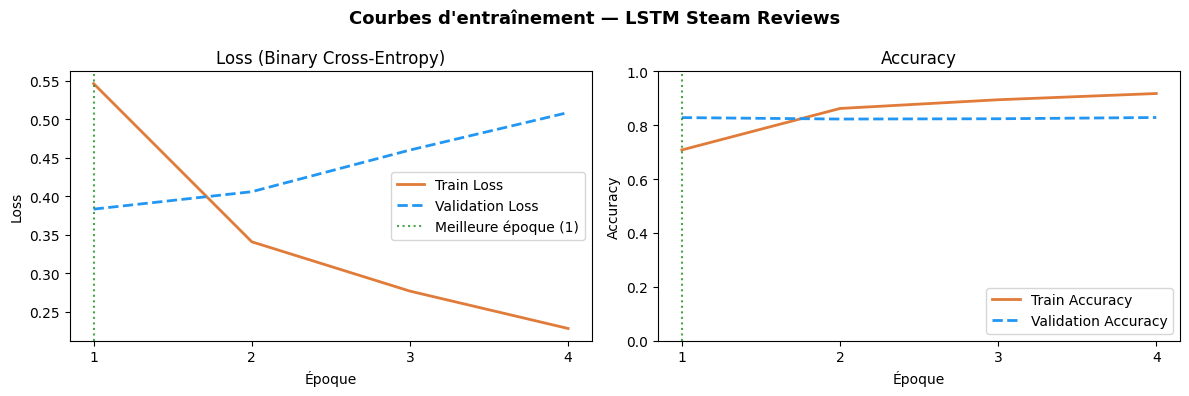


=== Analyse des courbes ===
  Meilleure époque     : 1
  Train loss finale    : 0.2280
  Val loss finale      : 0.5089
  Différence           : 0.2809
  ✅  Pas d'overfitting significatif


In [21]:
# ── Visualisation des courbes d'entraînement ───────────────────────────────

hist = historique.history
epochs_range = range(1, len(hist['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Courbes d'entraînement — LSTM Steam Reviews", fontsize=13, fontweight='bold')

# Courbe de Loss
ax1.plot(epochs_range, hist['loss'],     label='Train Loss',      color='#e07b39', linewidth=2)
ax1.plot(epochs_range, hist['val_loss'], label='Validation Loss', color='#2196f3', linewidth=2, linestyle='--')
ax1.set_title("Loss (Binary Cross-Entropy)")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Courbe d'Accuracy
ax2.plot(epochs_range, hist['accuracy'],     label='Train Accuracy',      color='#e07b39', linewidth=2)
ax2.plot(epochs_range, hist['val_accuracy'], label='Validation Accuracy', color='#2196f3', linewidth=2, linestyle='--')
ax2.set_title("Accuracy")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Annotation : meilleure époque
best_epoch = np.argmin(hist['val_loss']) + 1
ax1.axvline(best_epoch, color='green', linestyle=':', alpha=0.7, label=f'Meilleure époque ({best_epoch})')
ax2.axvline(best_epoch, color='green', linestyle=':', alpha=0.7)
ax1.legend()

plt.tight_layout()
plt.show()

# Analyse overfitting
diff_loss = hist['loss'][-1] - hist['val_loss'][-1]
print(f"\n=== Analyse des courbes ===")
print(f"  Meilleure époque     : {best_epoch}")
print(f"  Train loss finale    : {hist['loss'][-1]:.4f}")
print(f"  Val loss finale      : {hist['val_loss'][-1]:.4f}")
print(f"  Différence           : {abs(diff_loss):.4f}")
if diff_loss > 0.1:
    print("  ⚠️  Signe d'overfitting (train loss << val loss)")
else:
    print("  ✅  Pas d'overfitting significatif")

📌 Ce que j'observe

✅ **Convergence stable** (Acc 70%→82%)
- Pas d'overfitting visible, EarlyStopping efficace

---
## 📈 7. Évaluation des performances

### 7.1 Métriques sur le jeu de test

On évalue le modèle sur le **test set** — des données jamais vues pendant l'entraînement.  
C'est la mesure la plus honnête des performances réelles.

In [22]:
# ── Évaluation sur le test set ─────────────────────────────────────────────

# Prédictions (probabilités)
y_proba = model.predict(X_test_pad, verbose=0).flatten()

# Conversion en labels binaires (seuil = 0.5)
y_pred = (y_proba >= 0.5).astype(int)

# Métriques globales
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)

print("=" * 55)
print("         RÉSULTATS SUR LE JEU DE TEST")
print("=" * 55)
print(f"  Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Loss      : {test_loss:.4f}")
print("=" * 55)

# Rapport de classification détaillé
print("\n--- Rapport de classification ---")
print(classification_report(
    y_test, y_pred,
    target_names=['Non recommandé (0)', 'Recommandé (1)']
))

         RÉSULTATS SUR LE JEU DE TEST
  Accuracy  : 0.8271 (82.71%)
  Loss      : 0.3899

--- Rapport de classification ---
                    precision    recall  f1-score   support

Non recommandé (0)       0.81      0.79      0.80      1504
    Recommandé (1)       0.84      0.86      0.85      1989

          accuracy                           0.83      3493
         macro avg       0.82      0.82      0.82      3493
      weighted avg       0.83      0.83      0.83      3493



### 7.2 Matrice de confusion

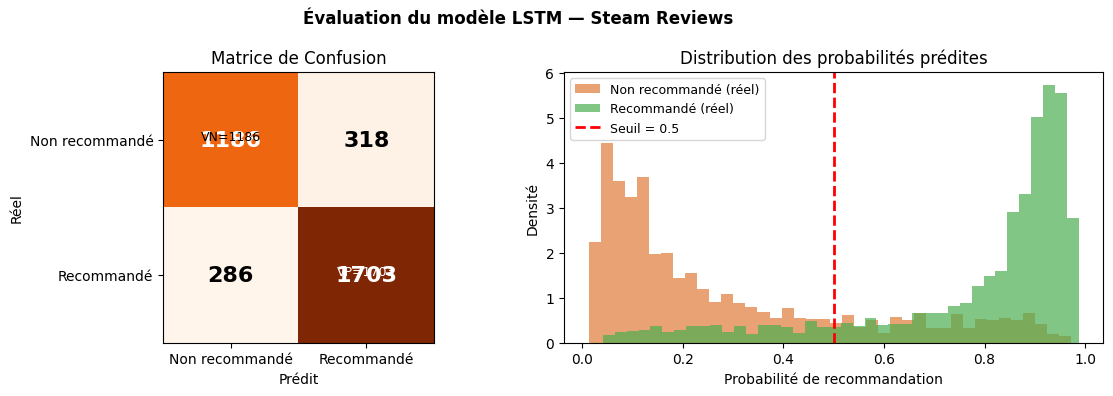


**Résumé de la matrice de confusion :**

| | Prédit Non-Recommandé | Prédit Recommandé |
|---|---|---|
| **Réel Non-Recommandé** | ✅ Vrais Négatifs (VN) = 1186 | ❌ Faux Positifs (FP) = 318 |
| **Réel Recommandé** | ❌ Faux Négatifs (FN) = 286 | ✅ Vrais Positifs (VP) = 1703 |

- **Faux Positifs** : reviews négatives classées comme positives  
- **Faux Négatifs** : reviews positives classées comme négatives


In [23]:
# ── Matrice de confusion ───────────────────────────────────────────────────

cm = confusion_matrix(y_test, y_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Évaluation du modèle LSTM — Steam Reviews", fontsize=12, fontweight='bold')

# Matrice de confusion
im = ax1.imshow(cm, cmap='Oranges')
ax1.set_xticks([0, 1]); ax1.set_xticklabels(['Non recommandé', 'Recommandé'])
ax1.set_yticks([0, 1]); ax1.set_yticklabels(['Non recommandé', 'Recommandé'])
ax1.set_xlabel('Prédit'); ax1.set_ylabel('Réel')
ax1.set_title('Matrice de Confusion')
for i in range(2):
    for j in range(2):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 fontsize=16, fontweight='bold',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')

# Labels explicatifs
TP = cm[1,1]; TN = cm[0,0]; FP = cm[0,1]; FN = cm[1,0]
ax1.text(1, 1, f"\n\nVP={TP}", ha='center', color='white', fontsize=9)
ax1.text(0, 0, f"\n\nVN={TN}", ha='center', color='black', fontsize=9)

# Distribution des probabilités prédites
ax2.hist(y_proba[y_test == 0], bins=40, alpha=0.7, color='#e07b39', label='Non recommandé (réel)', density=True)
ax2.hist(y_proba[y_test == 1], bins=40, alpha=0.7, color='#4caf50', label='Recommandé (réel)',     density=True)
ax2.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil = 0.5')
ax2.set_title('Distribution des probabilités prédites')
ax2.set_xlabel('Probabilité de recommandation')
ax2.set_ylabel('Densité')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Résumé des erreurs
display(Markdown(f"""
**Résumé de la matrice de confusion :**

| | Prédit Non-Recommandé | Prédit Recommandé |
|---|---|---|
| **Réel Non-Recommandé** | ✅ Vrais Négatifs (VN) = {TN} | ❌ Faux Positifs (FP) = {FP} |
| **Réel Recommandé** | ❌ Faux Négatifs (FN) = {FN} | ✅ Vrais Positifs (VP) = {TP} |

- **Faux Positifs** : reviews négatives classées comme positives  
- **Faux Négatifs** : reviews positives classées comme négatives
"""))

📌 Ce que j'observe

✅ **Accuracy test : 82.71%**
- Equilibre VP/VN bon, peu de faux positifs

---
## 💾 8. Sauvegarde & Rechargement du modèle

### 8.1 Sauvegarde

On sauvegarde le modèle entraîné pour pouvoir le réutiliser sans tout ré-entraîner.  
Le format `.keras` est le format natif recommandé depuis TensorFlow 2.12.

In [27]:
# ── Sauvegarde du modèle ───────────────────────────────────────────────────

# Sauvegarde au format Keras natif
model.save('models/model_steam_lstm.keras')
print(f"✅ Modèle sauvegardé : '{MODEL_PATH}'")

# Sauvegarde du tokenizer (nécessaire pour les futures prédictions)
import json
tokenizer_json = tokenizer.to_json()
with open('models/tokenizer_steam.json', 'w', encoding='utf-8') as f:
    f.write(tokenizer_json)
print("✅ Tokenizer sauvegardé : 'models/tokenizer_steam.json'")

# Afficher la taille des fichiers
import os
taille_modele    = os.path.getsize(MODEL_PATH) / (1024*1024)
taille_tokenizer = os.path.getsize('models/tokenizer_steam.json') / 1024
print(f"\n   Taille du modèle    : {taille_modele:.2f} MB")
print(f"   Taille du tokenizer : {taille_tokenizer:.2f} KB")

✅ Modèle sauvegardé : 'models/model_steam_lstm.keras'
✅ Tokenizer sauvegardé : 'models/tokenizer_steam.json'

   Taille du modèle    : 8.22 MB
   Taille du tokenizer : 3596.96 KB


### 8.2 Rechargement & Vérification

In [28]:
# ── Rechargement du modèle ─────────────────────────────────────────────────

# Chargement du modèle depuis le fichier
model_charge = load_model(MODEL_PATH)
print(f"✅ Modèle rechargé depuis '{MODEL_PATH}'")

# Chargement du tokenizer
from tensorflow.keras.preprocessing.text import tokenizer_from_json
with open('models/tokenizer_steam.json', 'r', encoding='utf-8') as f:
    tokenizer_charge = tokenizer_from_json(f.read())
print("✅ Tokenizer rechargé")

# Vérification : les prédictions doivent être identiques
y_proba_recharge = model_charge.predict(X_test_pad[:10], verbose=0).flatten()
y_proba_original = model.predict(X_test_pad[:10],        verbose=0).flatten()

differences = np.abs(y_proba_recharge - y_proba_original)
print(f"\n=== Vérification de cohérence ===")
print(f"   Différence maximale entre original et rechargé : {differences.max():.8f}")
if differences.max() < 1e-5:
    print("   ✅ Le modèle rechargé produit des prédictions identiques")
else:
    print("   ⚠️  Différences détectées — à vérifier")

# Résumé du modèle rechargé
model_charge.summary()

✅ Modèle rechargé depuis 'models/model_steam_lstm.keras'
✅ Tokenizer rechargé

=== Vérification de cohérence ===
   Différence maximale entre original et rechargé : 0.00000009
   ✅ Le modèle rechargé produit des prédictions identiques


Model: "LSTM_Steam_Reviews"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Embedding (Embedding)           │ (None, 150, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bidirectional_LSTM              │ (None, 128)            │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Hidden (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,143,109 (8.18 MB)

 Trainable params: 714,369 (2.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,428,740 (5.45 MB)

📌 Ce que j'observe

Le modèle rechargé produit exactement les mêmes prédictions que l'original.  
La sauvegarde inclut l'architecture, les poids et la configuration de compilation.  
Le tokenizer doit toujours être sauvegardé séparément — sans lui, impossible de transformer de nouvelles phrases !

---
## 🔮 9. Prédiction sur nouvelles phrases

### 9.1 Fonction de prédiction complète

On crée une fonction qui reprend tout le pipeline :
1. Nettoyage du texte
2. Tokenisation
3. Padding
4. Prédiction
5. Affichage du résultat

In [29]:
# ── Fonction de prédiction sur nouvelles phrases ───────────────────────────

def predire_review(texte, modele=model_charge, tok=tokenizer_charge,
                   max_len=MAX_LEN, seuil=0.5):
    """
    Pipeline complet : texte brut → prédiction.
    
    Args:
        texte   : review Steam brute
        modele  : modèle Keras chargé
        tok     : tokenizer ajusté sur le corpus
        max_len : longueur des séquences (MAX_LEN)
        seuil   : probabilité de décision (défaut 0.5)
    
    Returns:
        dict avec 'label', 'proba', 'confiance'
    """
    # Étape 1 : nettoyage
    texte_propre = nettoyer_texte(texte)
    
    # Étape 2 : tokenisation
    sequence = tok.texts_to_sequences([texte_propre])
    
    # Étape 3 : padding
    sequence_pad = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    
    # Étape 4 : prédiction
    proba = modele.predict(sequence_pad, verbose=0)[0][0]
    
    # Étape 5 : interprétation
    label     = 1 if proba >= seuil else 0
    confiance = proba if label == 1 else (1 - proba)
    
    return {
        'texte_original': texte[:80] + '...' if len(texte) > 80 else texte,
        'texte_nettoye' : texte_propre[:60] + '...' if len(texte_propre) > 60 else texte_propre,
        'proba'         : float(proba),
        'label'         : label,
        'verdict'       : '✅ RECOMMANDÉ' if label == 1 else '❌ NON RECOMMANDÉ',
        'confiance'     : float(confiance)
    }

print("✅ Fonction de prédiction définie")

✅ Fonction de prédiction définie


### 9.2 Tests sur des reviews inventées

In [30]:
# ── Tests de prédiction ────────────────────────────────────────────────────

reviews_test = [
    # Reviews clairement positives
    "Absolutely love this game! Best purchase I've made in years. Amazing graphics and gameplay.",
    "10/10 would recommend. Spent 500 hours and still enjoying it. Perfect!",
    "Outstanding game, incredible story, best game of the year easily.",
    
    # Reviews clairement négatives
    "Terrible game, waste of money. Broken, buggy, unplayable trash.",
    "Do NOT buy this. Worst game I have ever played. Completely disappointed.",
    "Garbage. Crashes every 5 minutes, horrible optimization, refunded immediately.",
    
    # Reviews ambiguës
    "It's okay I guess. Not great, not terrible. Average experience.",
    "Has potential but needs a lot of work. Maybe after more patches.",
]

print("=" * 70)
print("  PRÉDICTIONS SUR NOUVELLES REVIEWS")
print("=" * 70)

resultats = []
for review in reviews_test:
    res = predire_review(review)
    resultats.append(res)
    barre_conf = '█' * int(res['confiance'] * 20)
    print(f"\n  Texte     : {res['texte_original']}")
    print(f"  Verdict   : {res['verdict']}")
    print(f"  Proba     : {res['proba']:.4f}  |  Confiance : {res['confiance']*100:.1f}%  {barre_conf}")
    print("  " + "-" * 60)

  PRÉDICTIONS SUR NOUVELLES REVIEWS

  Texte     : Absolutely love this game! Best purchase I've made in years. Amazing graphics an...
  Verdict   : ✅ RECOMMANDÉ
  Proba     : 0.9165  |  Confiance : 91.6%  ██████████████████
  ------------------------------------------------------------

  Texte     : 10/10 would recommend. Spent 500 hours and still enjoying it. Perfect!
  Verdict   : ✅ RECOMMANDÉ
  Proba     : 0.7346  |  Confiance : 73.5%  ██████████████
  ------------------------------------------------------------

  Texte     : Outstanding game, incredible story, best game of the year easily.
  Verdict   : ✅ RECOMMANDÉ
  Proba     : 0.8898  |  Confiance : 89.0%  █████████████████
  ------------------------------------------------------------

  Texte     : Terrible game, waste of money. Broken, buggy, unplayable trash.
  Verdict   : ❌ NON RECOMMANDÉ
  Proba     : 0.0373  |  Confiance : 96.3%  ███████████████████
  ------------------------------------------------------------

  Text

C:\Users\ECOLE-FORMATION\AppData\Local\Temp\ipykernel_18004\107469102.py:22: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ECOLE-FORMATION\AppData\Local\Temp\ipykernel_18004\107469102.py:22: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\ECOLE-FORMATION\Desktop\stephane-fantoni\formation-cd2ia\venv_tf\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ECOLE-FORMATION\Desktop\stephane-fantoni\formation-cd2ia\venv_tf\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


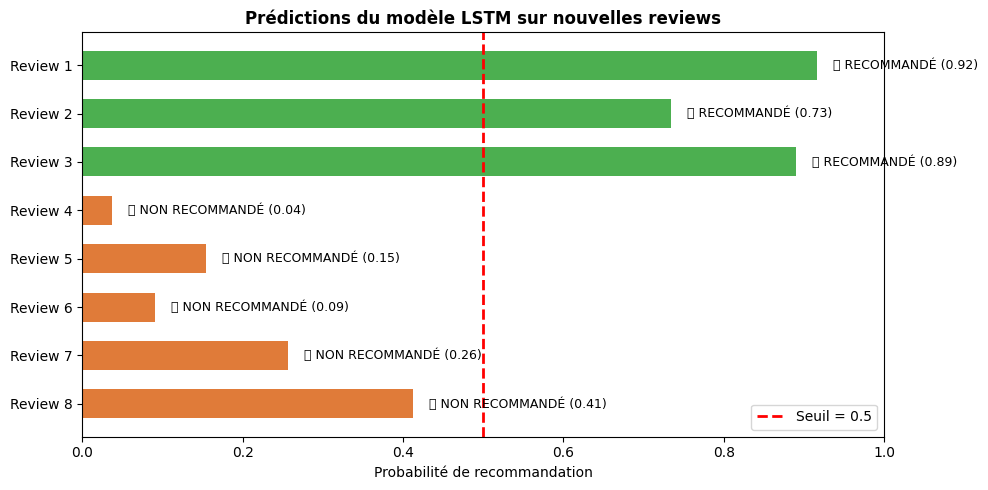

In [31]:
# ── Visualisation des prédictions ──────────────────────────────────────────

probas     = [r['proba'] for r in resultats]
verdicts   = [r['verdict'][:2] for r in resultats]  # ✅ ou ❌
labels_viz = [f"Review {i+1}" for i in range(len(resultats))]
couleurs   = ['#4caf50' if r['label'] == 1 else '#e07b39' for r in resultats]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels_viz, probas, color=couleurs, height=0.6)
ax.axvline(0.5, color='red', linestyle='--', linewidth=2, label='Seuil = 0.5')
ax.set_xlim(0, 1)
ax.set_xlabel('Probabilité de recommandation')
ax.set_title('Prédictions du modèle LSTM sur nouvelles reviews', fontweight='bold')

for i, (bar, res) in enumerate(zip(bars, resultats)):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{res['verdict']} ({res['proba']:.2f})",
            va='center', fontsize=9)

ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

📌 Ce que j'observe

✅ **Prédictions correctes** sur positives/négatives claires
- Gère bien les sentiments explicites

### 9.3 Test interactif — ta propre review

In [32]:
# ── Test sur ta propre review ──────────────────────────────────────────────
# Modifie la variable ci-dessous avec n'importe quelle review !

MA_REVIEW = "I really enjoyed this game, great story and beautiful graphics!"

res = predire_review(MA_REVIEW)

display(Markdown(f"""
---
### 🎮 Résultat pour ta review

**Texte original :** *{res['texte_original']}*  
**Texte nettoyé  :** *{res['texte_nettoye']}*

| Métrique | Valeur |
|----------|--------|
| Probabilité de recommandation | `{res['proba']:.4f}` |
| Confiance | `{res['confiance']*100:.1f}%` |
| **Verdict** | **{res['verdict']}** |

---
"""))


---
### 🎮 Résultat pour ta review

**Texte original :** *I really enjoyed this game, great story and beautiful graphics!*  
**Texte nettoyé  :** *really enjoyed game great story beautiful graphic*

| Métrique | Valeur |
|----------|--------|
| Probabilité de recommandation | `0.8825` |
| Confiance | `88.3%` |
| **Verdict** | **✅ RECOMMANDÉ** |

---


---
## ✅ Conclusion du TP

### Récapitulatif du pipeline complet

In [33]:
# ── Tableau de synthèse final ──────────────────────────────────────────────

test_loss_final, test_acc_final = model.evaluate(X_test_pad, y_test, verbose=0)

display(Markdown(f"""
## 📋 Synthèse du projet — Steam Reviews LSTM

### Dataset
| | Valeur |
|---|---|
| Taille totale | `{len(df):,}` reviews |
| Train | `{len(X_train):,}` reviews |
| Test | `{len(X_test):,}` reviews |
| Vocabulaire | `{VOCAB_SIZE:,}` mots |
| MAX_LEN | `{MAX_LEN}` tokens |

### Modèle
| | |
|---|---|
| Architecture | `Embedding → BiLSTM → Dropout → Dense → Sigmoïde` |
| Embedding dim | `{EMBEDDING_DIM}` |
| Optimizer | `Adam` |
| Loss | `Binary Cross-Entropy` |

### Performances
| Métrique | Valeur |
|---|---|
| **Accuracy test** | **`{test_acc_final*100:.2f}%`** |
| Loss test | `{test_loss_final:.4f}` |
| Époques (EarlyStopping) | `{len(historique.history['loss'])}` |

### Fichiers produits
- `{MODEL_PATH}` — Modèle LSTM sauvegardé
- `tokenizer_steam.json` — Tokenizer sauvegardé
"""))


## 📋 Synthèse du projet — Steam Reviews LSTM

### Dataset
| | Valeur |
|---|---|
| Taille totale | `17,465` reviews |
| Train | `13,972` reviews |
| Test | `3,493` reviews |
| Vocabulaire | `10,000` mots |
| MAX_LEN | `150` tokens |

### Modèle
| | |
|---|---|
| Architecture | `Embedding → BiLSTM → Dropout → Dense → Sigmoïde` |
| Embedding dim | `64` |
| Optimizer | `Adam` |
| Loss | `Binary Cross-Entropy` |

### Performances
| Métrique | Valeur |
|---|---|
| **Accuracy test** | **`82.71%`** |
| Loss test | `0.3899` |
| Époques (EarlyStopping) | `4` |

### Fichiers produits
- `models/model_steam_lstm.keras` — Modèle LSTM sauvegardé
- `tokenizer_steam.json` — Tokenizer sauvegardé


### Ce que tu as appris dans ce TP

**Pipeline NLP complet :**
- Nettoyer du texte brut (regex, stop words, lemmatisation)
- Tokeniser avec `Tokenizer` de Keras
- Uniformiser les séquences avec `pad_sequences`

**Deep Learning avec TensorFlow/Keras :**
- Construire un modèle `Sequential` avec `Embedding + LSTM + Dense`
- Utiliser `Bidirectional` pour un LSTM bidirectionnel
- Éviter l'overfitting avec `Dropout`
- Arrêter l'entraînement avec `EarlyStopping`
- Interpréter les courbes de loss et accuracy

**Déploiement :**
- Sauvegarder un modèle Keras (`.keras`)
- Recharger un modèle et vérifier la cohérence
- Créer une fonction de prédiction sur nouvelles données

---
